In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer

In [24]:
data_path = Path().cwd() / 'data'
data_df = pd.read_csv(data_path / 'transactions_obf.csv', parse_dates=['transactionTime'])
data_df.sort_values(by='transactionTime', inplace=True)
data_df.head()

,transactionTime,eventId,accountNumber,merchantId,mcc,merchantCountry,merchantZip,posEntryMode,transactionAmount,availableCash
0,2017-01-01 00:00:00+00:00,18688431A1,94f9b4e7,b76d06,5968,826,CR0,1,10.72,7500
3,2017-01-01 00:15:07+00:00,11162049A1,038099dd,7d5803,5499,826,NR1,81,21.00,7500
4,2017-01-01 00:37:09+00:00,17067235A1,3130363b,12ca76,5411,826,M50,81,47.00,10500
2,2017-01-01 00:43:17+00:00,31294145A1,c0ffab1b,94cafc,5735,442,NaN,81,5.04,9500
1,2017-01-01 00:49:03+00:00,2164986A1,648e19cf,718cc6,5499,826,DE14,81,21.19,4500


In [25]:
data_df[['mcc', 'merchantCountry', 'posEntryMode']] = data_df[['mcc', 'merchantCountry', 'posEntryMode']].astype(object)

In [26]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118621 entries, 0 to 118619
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   transactionTime    118621 non-null  datetime64[ns, UTC]
 1   eventId            118621 non-null  object             
 2   accountNumber      118621 non-null  object             
 3   merchantId         118621 non-null  object             
 4   mcc                118621 non-null  object             
 5   merchantCountry    118621 non-null  object             
 6   merchantZip        95616 non-null   object             
 7   posEntryMode       118621 non-null  object             
 8   transactionAmount  118621 non-null  float64            
 9   availableCash      118621 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(1), int64(1), object(7)
memory usage: 10.0+ MB


In [27]:
print(f'Number of missing values:\n{data_df.isnull().sum()}')

Number of missing values:
transactionTime          0
eventId                  0
accountNumber            0
merchantId               0
mcc                      0
merchantCountry          0
merchantZip          23005
posEntryMode             0
transactionAmount        0
availableCash            0
dtype: int64


In [28]:
print(f'Percentage of missing values:\n{round(100*data_df.isnull().sum()/data_df.shape[0], 1)}')

Percentage of missing values:
transactionTime       0.0
eventId               0.0
accountNumber         0.0
merchantId            0.0
mcc                   0.0
merchantCountry       0.0
merchantZip          19.4
posEntryMode          0.0
transactionAmount     0.0
availableCash         0.0
dtype: float64


In [29]:
print(f'Number of unique entries:\n{data_df.nunique().sort_values(ascending=False)}')

Number of unique entries:
eventId              118621
transactionTime      118105
merchantId            33327
transactionAmount     16431
merchantZip            3260
accountNumber           766
mcc                     361
merchantCountry          82
availableCash            19
posEntryMode             10
dtype: int64


In [30]:
data_df.merchantZip.value_counts(dropna=False, normalize=True)[:10]

merchantZip
NaN     0.193937
0       0.122019
E12     0.009644
SL4     0.005496
LS11    0.005151
CO10    0.004637
HA8     0.004578
AL10    0.004578
NW4     0.004460
IV30    0.004426
Name: proportion, dtype: float64

In [31]:
print(f'''Percentage of NAs and 0s in 'merchantZip': {round(100*((data_df.merchantZip == '0').sum() + data_df.merchantZip.isna().sum())/data_df.shape[0], 2)}%.''')

Percentage of NAs and 0s in 'merchantZip': 31.6%.


In [32]:
data_df.drop('merchantZip', axis=1, inplace=True)

In [33]:
data_path = Path().cwd() / 'data'
labels_df = pd.read_csv(data_path / 'labels_obf.csv', parse_dates=['reportedTime'])
labels_df.sort_values(by='reportedTime', inplace=True)
labels_df.head()

,reportedTime,eventId
0,2017-01-04 00:00:00+00:00,101536329A1
1,2017-01-04 00:00:00+00:00,101536425A1
2,2017-01-04 00:00:00+00:00,101536473A1
3,2017-01-04 00:00:00+00:00,101536617A1
4,2017-01-04 00:00:00+00:00,101536761A1


In [34]:
labels_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 875 entries, 0 to 874
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   reportedTime  875 non-null    datetime64[ns, UTC]
 1   eventId       875 non-null    object             
dtypes: datetime64[ns, UTC](1), object(1)
memory usage: 20.5+ KB


In [35]:
print(f'Number of unique entries in labels dataset:\n{labels_df.nunique()}')

Number of unique entries in labels dataset:
reportedTime    145
eventId         875
dtype: int64


In [36]:
data_df['fraudCase'] = data_df.eventId.isin(labels_df.eventId).astype(int)

In [37]:
data_df.head()

,transactionTime,eventId,accountNumber,merchantId,mcc,merchantCountry,posEntryMode,transactionAmount,availableCash,fraudCase
0,2017-01-01 00:00:00+00:00,18688431A1,94f9b4e7,b76d06,5968,826,1,10.72,7500,0
3,2017-01-01 00:15:07+00:00,11162049A1,038099dd,7d5803,5499,826,81,21.00,7500,0
4,2017-01-01 00:37:09+00:00,17067235A1,3130363b,12ca76,5411,826,81,47.00,10500,0
2,2017-01-01 00:43:17+00:00,31294145A1,c0ffab1b,94cafc,5735,442,81,5.04,9500,0
1,2017-01-01 00:49:03+00:00,2164986A1,648e19cf,718cc6,5499,826,81,21.19,4500,0


In [38]:
neg, pos = np.bincount(data_df['fraudCase'])
total = neg + pos
print('Total: {}\nPositive: {} ({:.2f}% of total)\n'.format(
    total, pos, 100 * pos / total))


Total: 118621
Positive: 875 (0.74% of total)



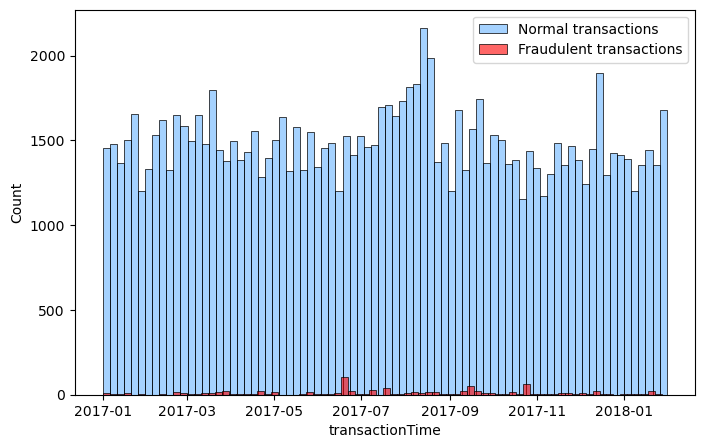

In [75]:
fig, ax = plt.subplots(figsize=(8,5))
transaction_df = data_df.transactionTime[data_df.fraudCase == 1]
sns.histplot(data_df.transactionTime, bins=80, alpha=0.4, color='dodgerblue', ax=ax,label='Normal transactions')
sns.histplot(transaction_df, bins=80, alpha=0.6, color='red', ax=ax, label='Fraudulent transactions')
plt.legend();

In [39]:
def mutual_info(x):
    return mutual_info_score(x, data_df.fraudCase)

In [40]:
categorical_list = list(data_df.select_dtypes('object'))
numerical_list = list(set(data_df) - set(data_df.select_dtypes('datetime64[ns, UTC]')) - set(data_df.select_dtypes('object')))

In [41]:
data_df[categorical_list].apply(mutual_info).sort_values(ascending=False)

eventId            0.043564
merchantId         0.031126
accountNumber      0.020102
mcc                0.008623
merchantCountry    0.006532
posEntryMode       0.006042
dtype: float64

In [42]:
data_df[numerical_list].corr()

,availableCash,fraudCase,transactionAmount
availableCash,1.000000,-0.051822,0.063817
fraudCase,-0.051822,1.000000,0.028863
transactionAmount,0.063817,0.028863,1.000000


In [46]:
dicts = data_df[categorical_list].to_dict(orient='records')
dv = DictVectorizer(sparse=False)
dicts_df = dv.fit_transform(dicts)

In [48]:
dicts_df.shape

(118621, 152717)